<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Contornos activos para segmentación.</h2>

### Contornos activos y *Morphological Snakes*
#### Author: Pedro Latorre Carmona

##### Curso 2025-2026

Versión 1.0

---

Tengo que añadir medidas de evaluacion a cada imagen a la que aplico los metodos. Estas medidas son sensibilidad Especificidad y Precisión Global. Las fórmulas estan en la diapositiva 81 del T4 de teoría.

Hay que ver que el numero corresponde correctamente con la representacion de la imagen y explicarlo

Sensibilidad y esecifidad del 50% es muy mala hay que intentar los mejores que se puedan

Hay que evaluar la calidad que da la segmentacion para cada una de las imágenes para cada uno de los métodos

Para evaluar la calidad hay que segementar una imagen a mano y comparar el resultado que nos da el programa con el nuestro. Es decir necesitaos la máscara

Crear y mostrar la marcara de cada segmentación que hacemos.

Tres imágenes en las que mostrar los resultados ecografía en escala de grises y lagos y estralla en color

Poner imagen comparativa máscaras

Invenstigar valor de alfa y beta etudio de variación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread
import imageio

# Importaciones de scikit-image (para el Objetivo 1)
from skimage.color import rgb2gray
from skimage import data
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# Importaciones del repositorio morphsnakes (para el Objetivo 1 y 2)
# (Asegúrate de que el archivo morphsnakes.py esté en el mismo directorio)
import morphsnakes as ms

### Objetivo 1

Será doble:

1) Probar si os funciona la implementación de *active contours* que hay en la siguiente página web:

https://scikit-image.org/docs/stable/auto_examples/edges/plot_active_contours.html

2) Intentar poner en funcionamiento la imagen de ejemplo de ecografía, y la metodología de *Snakes* que hay en el siguiente repositorio:

https://github.com/pmneila/morphsnakes/tree/master

Lo primero que os aconsejo es mirar y entender el código **examples.py**, e intentarlo hacer funcionar, con la imagen **mama07ORI.bmp**.

Es posible que necesitéis guardar variables en ficheros porque el entorno no os permita visualizar la evolución de la *snake*. Pensad qué podéis hacer para poder ver el resultado que os dé el método, teniendo en cuenta el **README.me** del repositorio.

Como paso intermedio entre 1) y 2), podéis probar la imagen de ecografía, con la metodología de 1).

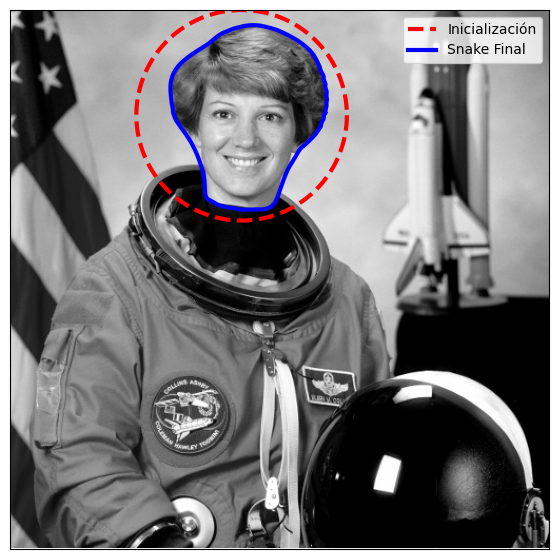

In [2]:
# Cargar imagen de ejemplo y convertir a escala de grises
img = data.astronaut()
img = rgb2gray(img)

# Crear una inicialización circular para la serpiente
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 100 * np.sin(s)
c = 220 + 100 * np.cos(s)
init = np.array([r, c]).T

# Aplicar el contorno activo
# 'snake' es la segmentación final
snake = active_contour(gaussian(img, 3, preserve_range=False),
                       init, alpha=0.015, beta=10, gamma=0.001)

# Mostrar resultados
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--r', lw=3, label='Inicialización')
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=3, label='Snake Final')
ax.set_xticks([]), ax.set_yticks([])
ax.axis([0, img.shape[1], img.shape[0], 0])
plt.legend()
plt.show()

C:\Users\fpabl\AppData\Local\Temp\ipykernel_26868\2889755088.py:38: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)[..., 0] / 255.0


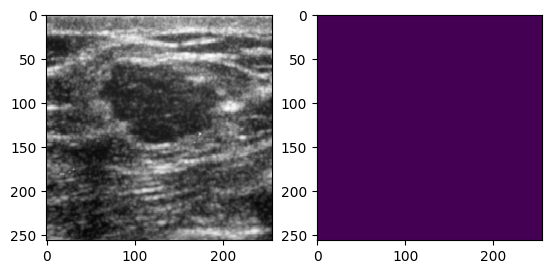

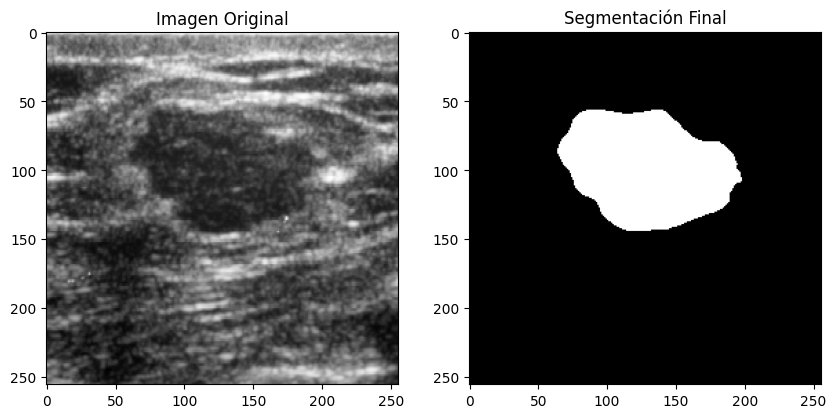

In [3]:
# --- Función de callback para visualización (de examples.py) ---
def visual_callback_2d(background, fig=None):
    """
    Función de callback para visualizar la evolución.
    """
    # Preparar el entorno visual
    if fig is None:
        fig = plt.figure()
    fig.clf()
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(background, cmap=plt.cm.gray)

    ax2 = fig.add_subplot(1, 2, 2)
    ax_u = ax2.imshow(np.zeros_like(background), vmin=0, vmax=1)
    plt.pause(0.001)

    def callback(levelset):

        # --- INICIO DE LA CORRECCIÓN ---
        # En lugar de .clear() o del, iteramos y eliminamos
        # cada contorno (artista) individualmente.
        if ax1.collections:
            for c in ax1.collections:
                c.remove()
        # --- FIN DE LA CORRECCIÓN ---
            
        ax1.contour(levelset, [0.5], colors='r')
        ax_u.set_data(levelset)
        fig.canvas.draw()
        plt.pause(0.001)

    return callback

# 1. Cargar la imagen del nódulo
img_path = 'images/mama07ORI.bmp'
# --- ESTA ES LA LÍNEA CORREGIDA (usando imageio.imread) ---

img = imageio.imread(img_path)[..., 0] / 255.0

# 2. Preprocesar la imagen para MorphGAC
gimg = ms.inverse_gaussian_gradient(img, alpha=1000, sigma=5.48)

# 3. Inicializar el level-set
init_ls = ms.circle_level_set(img.shape, (100, 126), 20)

# 4. Configurar el callback visual (¡asegúrate de que la función ya esté corregida!)
callback = visual_callback_2d(img)

# 5. Ejecutar MorphGAC
final_ls = ms.morphological_geodesic_active_contour(gimg, 
                                                    iterations=45,
                                                    init_level_set=init_ls,
                                                    smoothing=1, 
                                                    threshold=0.31,
                                                    balloon=1,
                                                    iter_callback=callback)

# 6. Mostrar el resultado final
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap=plt.cm.gray)
ax[0].set_title('Imagen Original')
ax[1].imshow(final_ls, cmap=plt.cm.gray)
ax[1].set_title('Segmentación Final')
plt.show()

C:\Users\fpabl\AppData\Local\Temp\ipykernel_26868\839655226.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imread(img_path)[..., 0] / 255.0


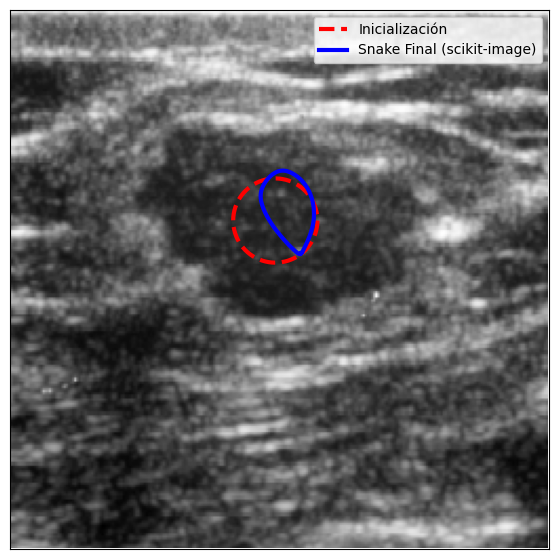

In [4]:
# 1. Cargar la imagen de ecografía
img_path = 'images/mama07ORI.bmp'
# La imagen ya está en escala de grises, normalizamos
img = imread(img_path)[..., 0] / 255.0

# 2. Inicializar la serpiente (círculo alrededor del nódulo)
# Ajustamos coordenadas y radio para esta imagen
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 20 * np.sin(s) # Fila (y)
c = 126 + 20 * np.cos(s) # Columna (x)
init = np.array([r, c]).T

# 3. Aplicar active_contour de scikit-image
# 'snake' es la segmentación final
# Es posible que se necesite ajustar los parámetros alpha, beta, gamma
snake = active_contour(gaussian(img, 1, preserve_range=False), 
                       init, 
                       alpha=0.1,  # Reducimos la contracción
                       beta=10.0,  # Aumentamos la suavidad
                       gamma=0.01)

# 4. Mostrar resultados
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--r', lw=3, label='Inicialización')
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=3, label='Snake Final (scikit-image)')
ax.set_xticks([]), ax.set_yticks([])
ax.axis([0, img.shape[1], img.shape[0], 0])
plt.legend()
plt.show()

---

### Objetivo 2

Intentad hacer funcionar el método sobre las imágenes en color **lakes3.jpg** y **seastar2.png**. 

---

C:\Users\fpabl\AppData\Local\Temp\ipykernel_26868\3958524090.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_color = imread(img_path) / 255.0


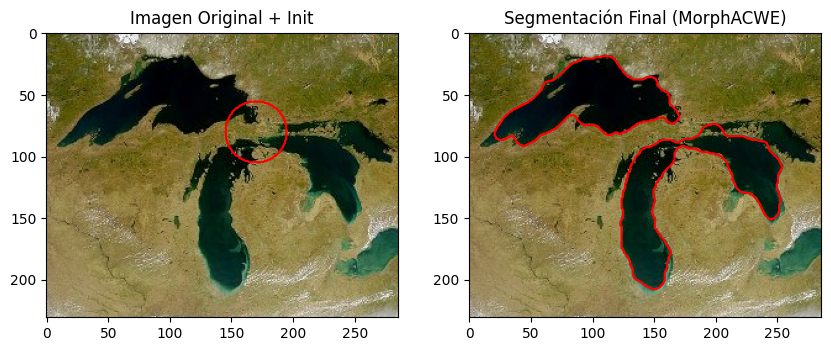

In [5]:
# Función para convertir a escala de grises (de examples.py)
def rgb2gray(img):
    return 0.2989 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]

# 1. Cargar la imagen en color y convertir a escala de grises
img_path = 'images/lakes3.jpg'
img_color = imread(img_path) / 255.0
img_gray = rgb2gray(img_color)

# 2. Inicializar el level-set (un círculo)
init_ls = ms.circle_level_set(img_gray.shape, (80, 170), 25)

# 3. Ejecutar MorphACWE (morphological_chan_vese)
# No necesita preprocesamiento g(I)
final_ls = ms.morphological_chan_vese(img_gray, 
                                      iterations=200,
                                      init_level_set=init_ls,
                                      smoothing=3, 
                                      lambda1=1, 
                                      lambda2=1)

# 4. Mostrar resultados
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_color)
ax[0].contour(init_ls, [0.5], colors='r') # Mostrar init
ax[0].set_title('Imagen Original + Init')
ax[1].imshow(img_color)
ax[1].contour(final_ls, [0.5], colors='r') # Mostrar final
ax[1].set_title('Segmentación Final (MorphACWE)')
plt.show()



C:\Users\fpabl\AppData\Local\Temp\ipykernel_26868\3285471857.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_color = imread(img_path) / 255.0


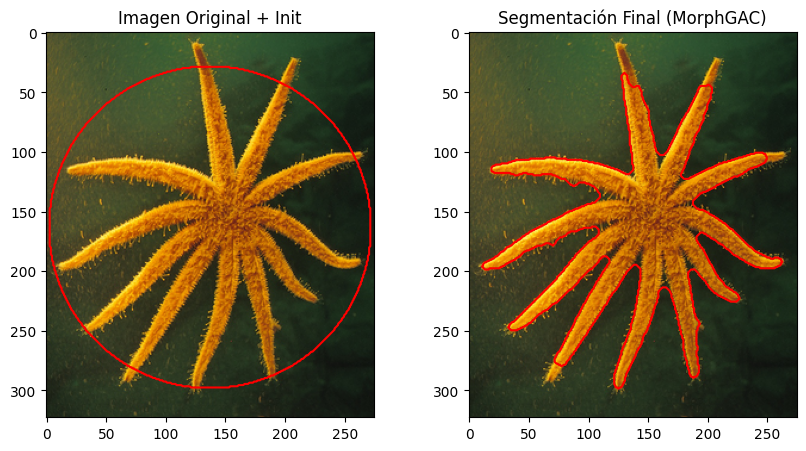

In [6]:
# Función para convertir a escala de grises (de examples.py)
def rgb2gray(img):
    return 0.2989 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]

# 1. Cargar la imagen en color y convertir a escala de grises
img_path = 'images/seastar2.png'
img_color = imread(img_path) / 255.0
img_gray = rgb2gray(img_color)

# 2. Preprocesar la imagen para MorphGAC (resaltar bordes)
gimg = ms.inverse_gaussian_gradient(img_gray, alpha=1000, sigma=2)

# 3. Inicializar el level-set (un círculo grande alrededor de la estrella)
init_ls = ms.circle_level_set(img_gray.shape, (163, 137), 135)

# 4. Ejecutar MorphGAC
# Usamos 'balloon=-1' para que el contorno se contraiga hacia los bordes
final_ls = ms.morphological_geodesic_active_contour(gimg, 
                                                    iterations=100,
                                                    init_level_set=init_ls,
                                                    smoothing=2, 
                                                    threshold=0.3,
                                                    balloon=-1)

# 5. Mostrar resultados
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_color)
ax[0].contour(init_ls, [0.5], colors='r') # Mostrar init
ax[0].set_title('Imagen Original + Init')
ax[1].imshow(img_color)
ax[1].contour(final_ls, [0.5], colors='r') # Mostrar final
ax[1].set_title('Segmentación Final (MorphGAC)')
plt.show()